# 基本指南

RAG: Retrieval-Augmented Generation检索增强生成

在LLM模型生成答案时候，**先从知识库检索**，再结合返回

所以完整步骤：
1. 检索：从知识库
2. 增强：将检索到的内容与原始问题合并，形成更强的Prompt
3. 生成：交给LLM大模型，生成回答

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
import os
os.getcwd()

## 数据准备

### 数据加载
- 加载出结构化数据。
- 结构化： 内容、类型、元信息、标签等

- UnstructuredMarkdownLoader 默认会把所有格式清楚，保留纯文本。比如#， ## 这些都会丢掉
- TextLoader 保留所有信息

In [1]:
from unstructured.partition.auto import partition

pdf_path = 'rag.pdf'

elements = partition(
    filename=pdf_path,
    content_type='application/pdf'
)

/home/dong/miniconda3/envs/data-analysis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Error downloading 'punkt_tab' from
[nltk_data]     <https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/packages/tokenizers/punkt_tab.zip>:   <urlopen
[nltk_data]     error [SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred
[nltk_data]     in violation of protocol (_ssl.c:1000)>
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be p

PDFInfoNotInstalledError: Unable to get page count. Is poppler installed and in PATH?

elements是解析出文本元素列表，每个元素有类型

In [ ]:
elements[0]

In [ ]:
len(elements)

In [ ]:
str(elements[0])

In [ ]:
print(f'解析出 {len(elements)} 个元素' )
print(f'一共 { sum(len(str(e)) for e in elements)}字符')


In [ ]:
elements[0].category

In [ ]:
for i,e in enumerate(elements):
    print(f'{i} {e.category} {e}')

### 文本分块
把上面的文档元素继续分块，是向量/模型处理的基本单位

LLM嵌入模型，一般都是长度限制的。所以我们要分块。
这类模型基于transformer架构：
- 分词：把文本切成一个个token
- 向量化：把token转成向量
- 池化降维：把向量池化成一个固定长度的向量。 这代表了这个文本的语义信息。

因此，我们应该尽可能让文本块尽可能精准表达，而非是一味追求长度添加噪声。

LangChain 给了几种分块策略

**固定长度**
- 基于段落分界感知
- 并非严格的固定，会尽量保证语义连续，比如段落
- 避免块之间语义分割，重叠 以保证上下文连续性
- 对于日志数据比较好

In [ ]:
from langchain.text_splitter import CharacterTextSplitter
from langchain_community.document_loaders import TextLoader

In [ ]:
loader = TextLoader(file_path='蜂医.txt')
docs = loader.load()

In [ ]:
docs

In [ ]:
text_splitter = CharacterTextSplitter(
    chunk_size = 200,
    chunk_overlap=10
)
chunks = text_splitter.split_documents(docs)

In [ ]:
chunks

**递归分块**
- 按照分隔符分块。 而非段落
- 先按段落分块，如果块太大，再按句子分块，如果还太大，再按词分块
- 对编程语言有着明确分隔符，效果较好。内置支持.

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
loader = TextLoader(file_path='蜂医.txt')
docs = loader.load()
text_splitter = RecursiveCharacterTextSplitter(
    separators = ["\n\n", "\n", "。", "，", " ", ""],  # 分隔符优先级
    chunk_size = 200,
    chunk_overlap=10
)
chunks = text_splitter.split_documents(docs)

In [ ]:
chunks

**语义分块**
- 智能，根据文本语义主题显著变化的地方分块。会调用模型判断边界

In [ ]:
import os
from langchain_experimental.text_splitter import SemanticChunker
from langchain_community.embeddings import HuggingFaceEmbeddings

In [ ]:
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-zh-v1.5",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

In [ ]:
text_splitter = SemanticChunker(
    embeddings,
)
chunks = text_splitter.split_documents(docs)

In [ ]:
chunks

**基于文档结构分块**
- html,md,latex有着明确的结构标签。


**其他分块策略**
- Unstructured也提供了分块策略：建立在解析元素上，都有元素类型。
- ChunkViz可视化分块 

## 索引构建

### 向量嵌入
- 就是将文本、图像等放在全局空间上，用一个向量表示
- 表示为向量后，我们可以度量

RAG检索以这个为基础：
1. 离线索引：知识文档分块后转为向量，存入向量数据库
2. 在线查询：输入问题转为向量
3. 相似度计算
4. 召回上下文：选取相似度最高的几个文本块，作为上下文，输入给LLM

现在的向量模型通常是BERT结构(transformer)：

MTEB (Massive Text Embedding Benchmark) 排行榜有各种向量模型

### 多模态嵌入
- 文本、图像、表格等都可以转为向量。 共享一个空间。

Hugging Face 是 AI 界的 GitHub。 有各种模型等.其中transformers 库提供各种预训练模型


CLIP模型；bge-visualized-m3模型

(BGE_VL_BASE)[https://huggingface.co/BAAI/BGE-VL-base]

以BGE_VL_BASE为例 ，Visual-Language (图文)

AutoModel 偏原生，提供了更多的底层接口，适合需要更细粒度控制的用户。

In [2]:
import os
os.getcwd()

'/home/dong/data-analysis/myrag'

In [3]:
import torch
from transformers import AutoModel

MODEL_NAME = "BAAI/BGE-VL-base" # or "BAAI/BGE-VL-large"

model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True) # You must set trust_remote_code=True
model.set_processor(MODEL_NAME)
model.eval()

/home/dong/miniconda3/envs/data-analysis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPSdpaAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e

In [4]:

with torch.no_grad():
    query = model.encode(
        images = "data/cir_query.png", 
        text = "Make the background dark, as if the camera has taken the photo at night"
    )
    print(f'query {query.shape}')
    candidates = model.encode(
        images = ["data/cir_candi_1.png", "data/cir_candi_2.png"]
    )
    print(f'candidate {candidates.shape}')
    scores = query @ candidates.T
print(scores)


query torch.Size([1, 512])
candidate torch.Size([2, 512])
tensor([[0.1971, 0.1242]])


In [7]:
query.squeeze().shape

torch.Size([512])

### 向量数据库
- 存储向量，相似度查询

FAISS 或者ChromaDB ：本地小型

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document

In [ ]:
texts = [
    "张三是法外狂徒",
    "FAISS是一个用于高效相似性搜索和密集向量聚类的库。",
    "LangChain是一个用于开发由语言模型驱动的应用程序的框架。"
]

In [ ]:
docs = [Document(page_content =t ) for t in texts]

In [ ]:
docs

In [ ]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-zh-v1.5")

创建

In [ ]:
vectorstore = FAISS.from_documents(docs, embeddings)


保存

In [ ]:
local_faiss_path = "./faiss_index_store"
vectorstore.save_local(local_faiss_path)

print(f"FAISS index has been saved to {local_faiss_path}")

加载

In [ ]:
loaded_vectorstore = FAISS.load_local(
    local_faiss_path,
    embeddings,
    allow_dangerous_deserialization=True
)

In [4]:
query = "张三是谁"
results = loaded_vectorstore.similarity_search(query, k=1)
print(f"查询: '{query}'")
print("相似度最高的文档:")
for doc in results:
    print(f"- {doc.page_content}")

NameError: name 'loaded_vectorstore' is not defined

### Milvus实践
这里使用milvus_lite轻量版说明

In [34]:
import pymilvus
print(pymilvus.__version__)

2.6.12


!()[https://datawhalechina.github.io/all-in-rag/chapter3/images/3_4_1.webp]

In [1]:
import os
from pymilvus import MilvusClient,FieldSchema, CollectionSchema,DataType

print(os.getcwd())

/home/dong/data-analysis/myrag


通用的encoder为多模态，使用之前的BAAI/BGE-VL-base 编码

In [30]:
import torch
from transformers import AutoModel

MODEL_NAME = "BAAI/BGE-VL-base" # or "BAAI/BGE-VL-large"

model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True) # You must set trust_remote_code=True
model.set_processor(MODEL_NAME)
encoder = model.eval()

In [2]:
COLLECTION_NAME = 'multimodal_demo'
MILVUS_URI = 'milvus_demo.db'
client = MilvusClient(MILVUS_URI)
if client.has_collection(COLLECTION_NAME):
    client.drop_collection(COLLECTION_NAME)
    

/home/dong/miniconda3/envs/data-analysis/lib/python3.12/site-packages/milvus_lite/__init__.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [32]:
DATA_DIR = 'data'

In [33]:
import glob
imgs = glob.glob(os.path.join(DATA_DIR, 'dragon', '*.png'))
imgs

['data/dragon/dragon05.png',
 'data/dragon/dragon04.png',
 'data/dragon/dragon06.png',
 'data/dragon/dragon02.png',
 'data/dragon/query.png',
 'data/dragon/dragon03.png',
 'data/dragon/other01.png']

In [34]:
encoder.encode(images=imgs[0]).shape

torch.Size([1, 512])

In [35]:
dim = encoder.encode(images=imgs[0]).shape[1]

In [36]:
dim

512

In [37]:
fields = [
    FieldSchema(name='id', dtype=DataType.INT64, is_primary=True,auto_id = True),
    FieldSchema(name='vector', dtype=DataType.FLOAT_VECTOR, dim = dim),
    FieldSchema(name="image_path", dtype=DataType.VARCHAR, max_length=512),
]

我们创建了3个字段，存储每个向量

In [38]:
schema = CollectionSchema(fields, description='多模态图文检索')

In [39]:
schema

{'auto_id': True, 'description': '多模态图文检索', 'fields': [{'name': 'id', 'description': '', 'type': <DataType.INT64: 5>, 'is_primary': True, 'auto_id': True}, {'name': 'vector', 'description': '', 'type': <DataType.FLOAT_VECTOR: 101>, 'params': {'dim': 512}}, {'name': 'image_path', 'description': '', 'type': <DataType.VARCHAR: 21>, 'params': {'max_length': 512}}], 'enable_dynamic_field': False, 'enable_namespace': False}

根据schema结构创建了一个集合（表）

In [40]:
client.create_collection(collection_name=COLLECTION_NAME, schema=schema)

In [41]:
print(client.describe_collection(COLLECTION_NAME))

{'collection_name': 'multimodal_demo', 'auto_id': True, 'num_shards': 0, 'description': '多模态图文检索', 'fields': [{'field_id': 100, 'name': 'id', 'description': '', 'type': <DataType.INT64: 5>, 'params': {}, 'auto_id': True, 'is_primary': True}, {'field_id': 101, 'name': 'vector', 'description': '', 'type': <DataType.FLOAT_VECTOR: 101>, 'params': {'dim': 512}}, {'field_id': 102, 'name': 'image_path', 'description': '', 'type': <DataType.VARCHAR: 21>, 'params': {'max_length': 512}}], 'functions': [], 'aliases': [], 'collection_id': 0, 'consistency_level': 0, 'properties': {}, 'num_partitions': 0, 'enable_dynamic_field': False, 'enable_namespace': False}


现在可以插入向量数据了

In [42]:
from tqdm import tqdm


In [43]:
data_insert= []
for img_path in tqdm(imgs, desc='生成向量'):
    with torch.no_grad():    
        vector = encoder.encode(images=img_path).numpy().squeeze().tolist() # 一维
    data_insert.append({
        'vector': vector,
        'image_path':img_path
    })
if data_insert:
    client.insert(collection_name=COLLECTION_NAME,
                data= data_insert
                )

生成向量:   0%|          | 0/7 [00:00<?, ?it/s]

生成向量: 100%|██████████| 7/7 [00:02<00:00,  2.81it/s]


为了快速检索，我们为vector字段其添加索引.

In [44]:
index_params = client.prepare_index_params()
index_params.add_index(
    field_name='vector',
    index_type='FLAT', # 索引类型
    metric_type="COSINE", # 度量比较方式
)
client.create_index(collection_name=COLLECTION_NAME, index_params=index_params)

In [45]:
client.describe_index(collection_name=COLLECTION_NAME, index_name='vector')

{'index_type': 'FLAT',
 'metric_type': 'COSINE',
 'dim': '512',
 'field_name': 'vector',
 'index_name': 'vector',
 'total_rows': 0,
 'indexed_rows': 0,
 'pending_index_rows': 0,
 'state': 'Finished'}

In [46]:
client.load_collection(collection_name=COLLECTION_NAME)

表加载到内存

查询

In [47]:
query_image_path = os.path.join(DATA_DIR, "dragon", "query.png")
query_text = "一条龙"

In [48]:
with torch.no_grad(): # 转换为普通向量，不带其他信息
    query_vector = encoder.encode(
        images = query_image_path,
        text = query_text
    )
    query_vector = query_vector.numpy().squeeze().tolist()

In [49]:
query_vector

[0.01725715957581997,
 0.023119034245610237,
 -0.007155007682740688,
 -0.004334800411015749,
 0.015785498544573784,
 -0.014036229811608791,
 0.022550037130713463,
 0.026307106018066406,
 -0.016902843490242958,
 0.012545951642096043,
 -0.024153610691428185,
 -0.0200381800532341,
 -0.03180725499987602,
 0.02135445922613144,
 0.00471658818423748,
 -0.0110956821590662,
 -0.01773425191640854,
 -0.00548075744882226,
 0.024504518136382103,
 0.023137202486395836,
 0.00022098403132986277,
 -0.04467716068029404,
 0.002974338596686721,
 0.058180760592222214,
 0.018238915130496025,
 0.011031615547835827,
 -0.0005261931801214814,
 -0.0019379250006750226,
 0.008150340989232063,
 -0.05595412850379944,
 0.03432084992527962,
 -0.003189715091139078,
 0.0033318372443318367,
 -0.0007683312869630754,
 0.10343178361654282,
 0.02090439945459366,
 -0.006991119589656591,
 -0.04578687995672226,
 0.046655502170324326,
 -0.013699943199753761,
 0.06486772000789642,
 -0.0036791316233575344,
 -0.028273137286305428,


In [50]:
search_results = client.search(
    collection_name=COLLECTION_NAME,
    data = [query_vector],
    output_fields=['image_path'],
    limit=5,
    search_params={"metric_type": "COSINE", "params": {"ef": 128}}

)[0]

In [51]:
search_results

[{'id': 465990001279631376, 'distance': 0.22547799348831177, 'entity': {'image_path': 'data/dragon/dragon06.png'}}, {'id': 465990001279631378, 'distance': 0.1865767538547516, 'entity': {'image_path': 'data/dragon/query.png'}}, {'id': 465990001279631377, 'distance': 0.1308782398700714, 'entity': {'image_path': 'data/dragon/dragon02.png'}}, {'id': 465990001279631379, 'distance': 0.10418923944234848, 'entity': {'image_path': 'data/dragon/dragon03.png'}}, {'id': 465990001279631374, 'distance': 0.09635187685489655, 'entity': {'image_path': 'data/dragon/dragon05.png'}}]

In [52]:
retrieved_images = []
print("检索结果:")
for i, hit in enumerate(search_results):
    print(f"  Top {i+1}: ID={hit['id']}, 距离={hit['distance']:.4f}, 路径='{hit['entity']['image_path']}'")
    retrieved_images.append(hit['entity']['image_path'])

检索结果:
  Top 1: ID=465990001279631376, 距离=0.2255, 路径='data/dragon/dragon06.png'
  Top 2: ID=465990001279631378, 距离=0.1866, 路径='data/dragon/query.png'
  Top 3: ID=465990001279631377, 距离=0.1309, 路径='data/dragon/dragon02.png'
  Top 4: ID=465990001279631379, 距离=0.1042, 路径='data/dragon/dragon03.png'
  Top 5: ID=465990001279631374, 距离=0.0964, 路径='data/dragon/dragon05.png'


In [90]:
from PIL import Image
import cv2
import numpy as np
def visualize_results(query_image_path: str, 
                      retrieved_images: list, 
                      img_height: int = 200, 
                      img_width: int = 200, 
                      row_count: int = 3) :
    # 画布
    panoramic_width = img_width * row_count
    panoramic_height = img_height * row_count
    panoramic_image = np.full((panoramic_height, panoramic_width, 3), fill_value=255, dtype=np.uint8)
    
    # 查询图片放在 左下
    query_display_area = np.full((panoramic_height, img_width, 3), fill_value=255, dtype=np.uint8)
    query_img_cv = cv2.imread(query_image_path)
    resized_query_img = cv2.resize(query_img_cv,  dsize= (img_width, img_height))
    border_query_img = cv2.copyMakeBorder(
        resized_query_img,
        top=3,
        bottom=3,
        left=3,
        right=3,
        borderType=cv2.BORDER_CONSTANT, # 常数填充
        value=(255,0,0)
    )
    query_display_area[img_height * (row_count - 1):, :] = cv2.resize(border_query_img, dsize= (img_width, img_height))
    cv2.putText(img=query_display_area,
            text='query',
            org=(10,panoramic_height - 20),
            fontFace=cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=1,
            color=(0,255,0),
            thickness=1
            )
    
    # 检索到的结果图片
    for i,img_path in enumerate(retrieved_images):
        row, col = i//row_count, i%row_count
        start_row, start_col = row*img_height, col*img_width
        retrieved_img_cv = cv2.imread(img_path)
        resized_retrieved_img = cv2.resize(retrieved_img_cv,  dsize= (img_width, img_height))
        border_retrieved_img = cv2.copyMakeBorder(
            resized_retrieved_img,
            top=1,
            bottom=1,
            left=1,
            right=1,
            borderType=cv2.BORDER_CONSTANT, # 常数填充
            value=(0,0,0)
        )
        panoramic_image[start_row:start_row+img_height, start_col:start_col+img_height] =cv2.resize(border_retrieved_img, dsize= (img_width, img_height))
        cv2.putText(img=panoramic_image,
            text=str(i),
            org=(start_col+10,start_row+ 30),
            fontFace=cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=1,
            color=(0,0,255),
            thickness=1
            )
    print(f'{query_display_area.shape}, {panoramic_image.shape}')
    return np.hstack([query_display_area,panoramic_image]) # 横向凭借

In [91]:
image = visualize_results(
    query_image_path=query_image_path,
    retrieved_images=retrieved_images
)
combined_img_path = os.path.join(DATA_DIR, 'search_results.png')
cv2.imwrite(filename=combined_img_path, img=image)

(600, 200, 3), (600, 600, 3)


True

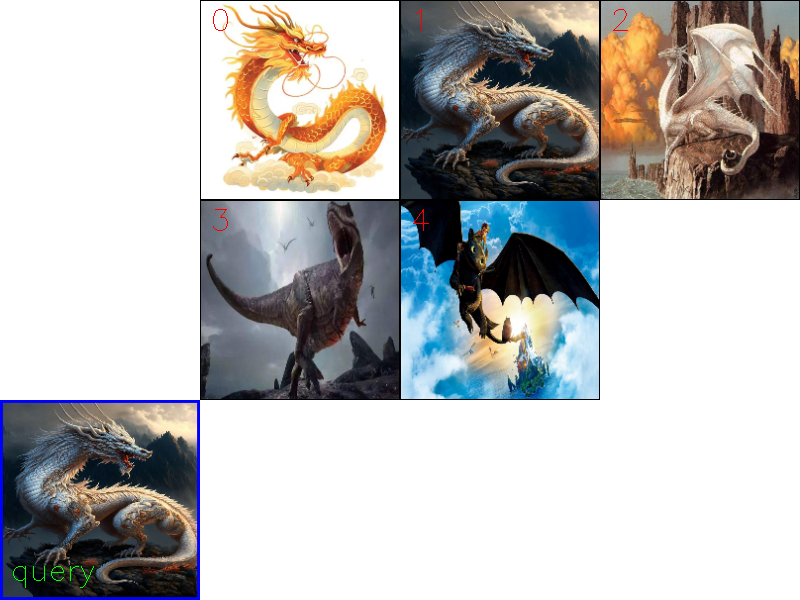

In [92]:
Image.open(combined_img_path).show()

确实很好的解释

### 索引优化

## 检索优化

### 混合检索：
稀疏向量：精确匹配。
稠密向量：语义匹配


- 稀疏向量。不能有意义的度量语义距离。
西红柿： [0,0,0...1,0...]
鸡蛋: [0,1..0..]
炒: [0,0,..1,..0]
如果搜索番茄炒蛋，因为西红柿和番茄不是一个东西，是理解不到的。

- 稠密向量。语义模型训练后。会转为一个都有值的。
西红柿炒蛋：[0.89, -0.12, 0.77, ..., -0.45]
番茄炒蛋：[0.1,...]
这是可以语义度量的

现实中，关键词更多指向语义，但是一些产品型号等则需要精确匹配。

所以要结合两种，来构建检索策略

embed_encoder = BGEM3EmbeddingFunction( 
    model_name='BAAI/bge-small-zh-v1.5', # Specify the model name
    device='cpu', # Specify the device to use
    use_fp16=False # 使用16位精度，加快速度
    )

对一个文本进行编码后，产生dense,sparse两种向量。但是不同的文字理解角度
- 稠密向量：整体含义
- 稀疏向量：关键词

### 查询构建

数据是多种多样的，比如SQL数据库，表格，图数据。

人们需求是复杂的，比如条件聚合等

查询构建：先使用LLM将自然语言翻译为特定格式的语言。才能连接各种类型数据。比如
- 为元数据查询。html或word等有标签的。
- 为图数据查询。cypher查询图数据库语言
- 为SQL结构化数据查询。 text2sql

#### **实现一个text2sql**

BAAI/bge-m3  文本向量嵌入比较好。

milvus内置了BGEM3EmbeddingFunction 易用

In [51]:
import json
import os
from typing import Any

In [52]:
from pymilvus.model.hybrid import BGEM3EmbeddingFunction
from pymilvus import MilvusClient,FieldSchema, CollectionSchema,DataType

- `BGEM3EmbeddingFunction`预置了一些维度。稠密dense:1024
- `BGEM3EmbeddingFunction`支持批量encode，可以传入texts list

In [2]:
BGEM3EmbeddingFunction().dim

NameError: name 'BGEM3EmbeddingFunction' is not defined

In [ ]:
class Knowledge:
    """ 知识库 向量数据库 """
    def __init__(self, milvus_uri: str ='milvus_demo.db'):
        self.client = MilvusClient(uri=os.path.join(os.getcwd(), milvus_uri))
        self.embedding_encoder = BGEM3EmbeddingFunction(    
            model_name='BAAI/bge-m3', # Specify the model name
            device='cpu', # Specify the device to use
            use_fp16=False)
        self.collection_name = 'text2sql_demo'
        self._setup_collection()
        self.load_data()
        print(f'Knowledge OK: {self.client.describe_collection(collection_name=self.collection_name)}')        

    def _setup_collection(self):
        # 初始化集合
        if self.client.has_collection(self.collection_name):
            self.client.drop_collection(self.collection_name)
        fields = [
            FieldSchema(name='pk', dtype=DataType.VARCHAR, is_primary= True, 
                        auto_id=True,max_length=100),
            FieldSchema(name='content', dtype=DataType.VARCHAR, max_length=1024),
            FieldSchema(name='type', dtype=DataType.VARCHAR, max_length=32), # ddl, sql,
            FieldSchema(name='dense_vector', dtype=DataType.FLOAT_VECTOR, 
                        dim=self.embedding_encoder.dim['dense'])
        ]
        schema = CollectionSchema(fields, description='多模态图文检索')
        self.client.create_collection(collection_name=self.collection_name, schema=schema)
        index_params = self.client.prepare_index_params()
        index_params.add_index(
            field_name='dense_vector',
            index_type='FLAT', # 索引类型
            metric_type="COSINE", # 度量比较方式
        )
        self.client.create_index(collection_name=self.collection_name, index_params=index_params)
    def load_data(self):
        """ 知识库 """
        # 1. ddl: 表结构定义
        # 2. 优秀问答，Q-SQL，供参考。
        # 3. 业务描述数据，理解字段
        data_dir = os.path.join(os.getcwd(), 'data')
        ddl_path = os.path.join(data_dir, 'users_ddl.json')
        if os.path.exists(ddl_path):
            with open(ddl_path, mode='r', encoding='utf-8') as f:
                ddl_data = json.load(f)
            self._add_ddl_data(ddl_data)
                
        # 加载Q->SQL数据
        qsql_path = os.path.join(data_dir, "users_qsql.json")
        if os.path.exists(qsql_path):
            with open(qsql_path, 'r', encoding='utf-8') as f:
                qsql_data = json.load(f)
            self._add_qsql_data(qsql_data)
        
        # 加载描述数据
        desc_path = os.path.join(data_dir, "users_descriptions.json")
        if os.path.exists(desc_path):
            with open(desc_path, 'r', encoding='utf-8') as f:
                desc_data = json.load(f)
            self._add_description_data(desc_data)
        
        # 加载集合到内存
        self.client.load_collection(collection_name=self.collection_name)
        print('知识已加载到向量数据库')
    def _add_ddl_data(self, data:list[dict]):
        """ 格式字符串化 ddl知识 """
        contents = []
        types = []
        for item in data:
            content = f'表名：{item.get('table_name', '')}\n'
            content += f'DDL: {item.get('ddl_statement', '')}\n'
            content += f'描述: {item.get('description', '')}\n'
            contents.append(content)
            types.append('ddl')
        self._insert_data(contents, types)

    def _add_qsql_data(self, data:list[dict]):
        """添加Q->SQL数据"""
        contents = []
        types = []
        
        for item in data:
            content = f"问题: {item.get('question', '')}\n"
            content += f"SQL: {item.get('sql', '')}"
            
            contents.append(content)
            types.append("qsql")
        
        self._insert_data(contents, types)
    
    def _add_description_data(self, data:list[dict]):
        """添加描述数据"""
        contents = []
        types = []
        for item in data:
            content = f"表名: {item.get('table_name', '')}\n"
            content += f"表描述: {item.get('table_description', '')}\n"
            columns = item.get('columns', [])
            if columns:
                content += "字段信息:\n"
                for col in columns:
                    content += f"  - {col.get('name', '')}: {col.get('description', '')} ({col.get('type', '')})\n"
            
            contents.append(content)
            types.append("description")
        self._insert_data(contents, types)
    def _insert_data(self, contents:list[str], types:list[str]):
        """ 插入到知识向量数据库 """
        if not contents: 
            return
        embeddings = self.embedding_encoder(contents)
        data_to_insert = []
        for i,c in enumerate(contents):
            data_to_insert.append({
                'content': contents[i],
                'dense_vector': embeddings['dense'][i],
                'type': types[i]
            })
        result = self.client.insert(
            collection_name=self.collection_name,
            data = data_to_insert
        )
    def search(self, query:str, top_k:int=5) ->list[dict[str, Any]]:
        """ 检索 """
        query_embeddings = self.embedding_encoder([query])
        search_results = self.client.search(
            collection_name=self.collection_name,
            data=query_embeddings['dense'],
            anns_field='dense_vector', # 目标搜索字段
            limit=top_k,
            output_fields=['content', 'type']
        )
        return search_results
    def __del__(self):
        client.close()

使用aihubmix提供的各种模型，使用OPenai客户端python库接入

In [54]:
from openai import OpenAI
class SQLGenerator:
    """ 自然语言转为sql """
    def __init__(self, api_key=None) -> None:
        self.llm = OpenAI(
            api_key=api_key or os.getenv('AIHUBMIX_API_KEY_XIAOMI'),
            base_url="https://aihubmix.com/v1",
        ) 
    def generate(self, user_query:str, knowledge_results:list[dict[str,Any]])->str:
        """ 生成sql，需要知识库结果 """
        # 构建知识上下文
        context = self._build_context(knowledge_results)
        # 提示：上下文-格式化
        prompt = f"""你是SQL专家。根据下面信息将用户问题转为SQL查询语句。
数据库信息：{context}
用户问题：{user_query}
要求：
1. 只返回SQL语句，不要包含任何解释和 ```sql 等标签
2. 确保SQL语法正确
3. 使用上下文提供表名和字段名
4. 如果需要join，根据表结构合理关联
SQL语句："""
        completion = self.llm.chat.completions.create(
            model='xiaomi-mimo-v2-omni-free',
            messages=[{"role": "user", "content": prompt}], # 必须是这种格式
            temperature=0.1
        )
        return completion.choices[0].message.content.strip()
    def fix_sql(self, original_sql:str, error_msg:str, knowledge_results:list[dict[str,Any]]) ->str:
        """ 矫正修复sql """
        context = self._build_context(knowledge_results)
        prompt = f"""
            请修复以下sql语句错误。
            数据库信息：{context}
            原始sql：{original_sql}
            错误信息：{error_msg}
            请返回修复后的sql语句（只有sql，不要解释）
            """
        completion = self.llm.chat.completions.create(
            model='xiaomi-mimo-v2-omni-free',
            messages=[{"role": "user", "content": prompt}], # 必须是这种格式
            temperature=0.1
        )
        return completion.choices[0].message.content.strip()
    def _build_context(self, knowledge_results:list[dict[str,Any]])->str:
        """ 构建LLM 的上下文信息 """
        ddl_info = []
        qsql_examples = []
        descriptions = []
        context = ''
        if ddl_info:
            context += '=== 表结构信息 ===\n'
        if descriptions:
            context += '=== 表和字段意义描述 ===\n'
        if qsql_examples:
            context += '=== 查询示例 ===\n'
        return context

In [62]:
import sqlite3
class Text2SQLAgent:
    """ 完整 """
    def __init__(self, db_path='users.db') -> None:
        self.knowledge = Knowledge()
        self.sql_generator = SQLGenerator()
        self.top_k_retrieval = 5
        self.max_result_rows = 100
        self.max_retry_count = 5
        self.conn = sqlite3.connect(db_path, check_same_thread=False)
        self.cursor = self.conn.cursor()
    def query(self, user_question:str) -> dict[str, Any]:
        """ 用户接口查询 """
        knowledge_results = self.knowledge.search(user_question)
        sql = self.sql_generator.generate(user_query=user_question, knowledge_results=knowledge_results)
        print(f'generated sql: {sql}')
        retry_count = 0
        while retry_count < self.max_retry_count:
            success, result = self._execute_sql(sql)
            if success:
                return {'success': True, 'sql': sql, 'results': result}
            else:
                sql = self.sql_generator.fix_sql(sql, result, knowledge_results)
                retry_count += 1
        return {'success': False, 'msg': 'max retry count.'}
    
    def _execute_sql(self, sql:str)-> tuple[bool, Any]:
        """ 执行SQL """
        if sql.strip().upper().startswith('SELECT'):
            try:
                self.cursor.execute(sql)
                # 获取列名和结果
                columns = [d[0] for d in self.cursor.description]
                data = self.cursor.fetchall()
                return True,{"status": "success", "columns": columns, "data": data}
            except Exception as e:
                return False,{"status": "error", "message": str(e)}
    def __del__(self):
        # 对象销毁时自动关闭连接
        self.conn.close()

In [56]:
agent = Text2SQLAgent()

Fetching 30 files: 100%|██████████| 30/30 [00:00<00:00, 57169.07it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


collection: {'collection_name': 'text2sql_demo', 'auto_id': True, 'num_shards': 0, 'description': '多模态图文检索', 'fields': [{'field_id': 100, 'name': 'pk', 'description': '', 'type': <DataType.VARCHAR: 21>, 'params': {'max_length': 100}, 'auto_id': True, 'is_primary': True}, {'field_id': 101, 'name': 'content', 'description': '', 'type': <DataType.VARCHAR: 21>, 'params': {'max_length': 1024}}, {'field_id': 102, 'name': 'type', 'description': '', 'type': <DataType.VARCHAR: 21>, 'params': {'max_length': 32}}, {'field_id': 103, 'name': 'dense_vector', 'description': '', 'type': <DataType.FLOAT_VECTOR: 101>, 'params': {'dim': 1024}}], 'functions': [], 'aliases': [], 'collection_id': 0, 'consistency_level': 0, 'properties': {}, 'num_partitions': 0, 'enable_dynamic_field': False, 'enable_namespace': False}
知识已加载到向量数据库
Knowledge OK


In [59]:
agent.query('按城市统计用户的平均年龄，只展示平均年龄大于 25 岁的城市，并按人数从多到少排序。')

{'success': True,
 'sql': 'SELECT city, AVG(age) AS average_age, COUNT(*) AS user_count\nFROM users\nGROUP BY city\nHAVING AVG(age) > 25\nORDER BY user_count DESC;',
 'results': {'status': 'success',
  'columns': ['city', 'average_age', 'user_count'],
  'data': [('青岛', 33.0, 1),
   ('长沙', 29.0, 1),
   ('西安', 27.0, 1),
   ('深圳', 28.0, 1),
   ('武汉', 42.0, 1),
   ('广州', 35.0, 1),
   ('南京', 31.0, 1),
   ('上海', 30.0, 1)]}}

In [60]:
agent.query('查询所有用户的姓名和年龄段，如果年龄小于 25 岁显示‘青年’，25 到 35 岁显示‘壮年’，其余显示‘资深’')

{'success': True,
 'sql': "SELECT name, CASE WHEN age < 25 THEN '青年' WHEN age BETWEEN 25 AND 35 THEN '壮年' ELSE '资深' END AS age_group FROM users;",
 'results': {'status': 'success',
  'columns': ['name', 'age_group'],
  'data': [('张三', '壮年'),
   ('李四', '壮年'),
   ('王五', '青年'),
   ('赵六', '壮年'),
   ('孙七', '壮年'),
   ('周八', '青年'),
   ('吴九', '资深'),
   ('郑十', '壮年'),
   ('陈十一', '壮年'),
   ('林十二', '青年'),
   ('韩十三', '壮年'),
   ('候十四', '青年'),
   ('蔡十五', '壮年')]}}

In [63]:
agent.query('帮我统计一下所有订单的总金额。')

{'success': False, 'msg': 'max retry count.'}

TEXT2SQL场景在哪里呢？ 整个速度都不如放到gpt翻译 后运行

### 查询重构和分发
用户的问题很多时候时充满歧义或者复杂的。我们要对其预处理
- 查询翻译：构建设计良好的prompt
- 查询路由：根据问题，分发到不同特点的数据库

面对复杂问题的时候，需要分解子问题，子主题。
比如Langchain 的`MultiQueryRe...`

退步提示： 将问题提升到更高层次、概括、原理。获取这个退步问题的答案，再结合具体的 。

`ChatPromptTemplate`提供了如何编写prompt指导
1. 提供各种消息角色支持：SystemMessage（设定 AI 行为）、HumanMessage（用户输入）和 AIMessage（模型历史回复）。
2. 提供占位
3. 可以传到LLM  messages输入

## 格式化生成
之前LLM都是返回一段文字。但是
- 表格生成
- 数据提取，格式化存储，每日新闻

Lanchain提供了

### Function calling
允许模型调用一些工具得到实时/精确的结果
1. 定义一些工具，参数等
2. 模型判断是否调用，
3. 应用工具代码执行
4. 模型得到结果，构造返回

In [ ]:
def get_weather(location):
    return f'20c'

工具说明的格式是严格的。受到不同客户端格式限制。如openai

In [3]:
# 工具说明
tools = [
    {
        'type': 'function',
        'function': {
            'name':'get_weather',
            'description': '获取指定城市的天气',
            'parameters': {
                'type': 'object',
                'properties': {
                    'location':{
                        'type': 'string',
                        'description': '城市名'
                    }
                },
                'required': ['location']
            }
        }
    }
]


In [4]:
from openai import OpenAI
import os
llm = OpenAI(
    api_key= os.getenv('AIHUBMIX_API_KEY_XIAOMI'),
    base_url="https://aihubmix.com/v1",
) 


In [6]:
messages = [{"role": "user", "content": '上海今天天气'}]
response = llm.chat.completions.create(
    model='xiaomi-mimo-v2-omni-free',
    messages=messages,
    tools= tools # 带上工具说明书
)

In [17]:
message1 = response.choices[0].message

可以看到没有返回content，而是由tool_calls 工具调用请求

我们得到这个信息，就可以调用了

In [10]:
tool_calls = response.choices[0].message.tool_calls

In [15]:
tool_calls[0]

ChatCompletionMessageFunctionToolCall(id='call_821b4d0ec7214f1cb555b1f2', function=Function(arguments='{"location": "上海"}', name='get_weather'), type='function')

In [18]:
if tool_calls:
    function_name = tool_calls[0].function.name
    parameters = tool_calls[0].function.arguments
    weather_info = get_weather("上海")
    messages.append(message1)
    messages.append({
        'role':'tool',
        'tool_call_id':tool_calls[0].id,
        'name': function_name,
        'content': weather_info
    })

messages构造好之后，再次给模型

In [19]:
final_response  = llm.chat.completions.create(
    model='xiaomi-mimo-v2-omni-free',
    messages=messages,
)

In [25]:
print(final_response.choices[0].message.content)

根据查询结果，**上海今天气温约 20°C**，是个比较舒适的温度。

不过由于获取的信息有限，建议您也可以查看天气App或网站，了解更详细的天气情况，比如：
- ☀️ 天气状况（晴/多云/雨）
- 💨 风力大小
- 💧 湿度

这个温度穿一件薄外套或长袖应该刚刚好，外出挺舒服的！您有什么出行计划吗？😊


其实经过了， 用户-模型-后台应用-模型-返回

## RAG评估
- 开发者：评估提升性能，问题定位
- 用户：如何再多个RAG应用选择

三个维度：
1. 上下文相关：检索到的上下文内容是否于 用户 查询高度相关。
2. 可信度：模型必须严格遵守上下文，不能捏造事实，自由发挥
3. 答案相关：不能答非所问，需要有效的回答问题。